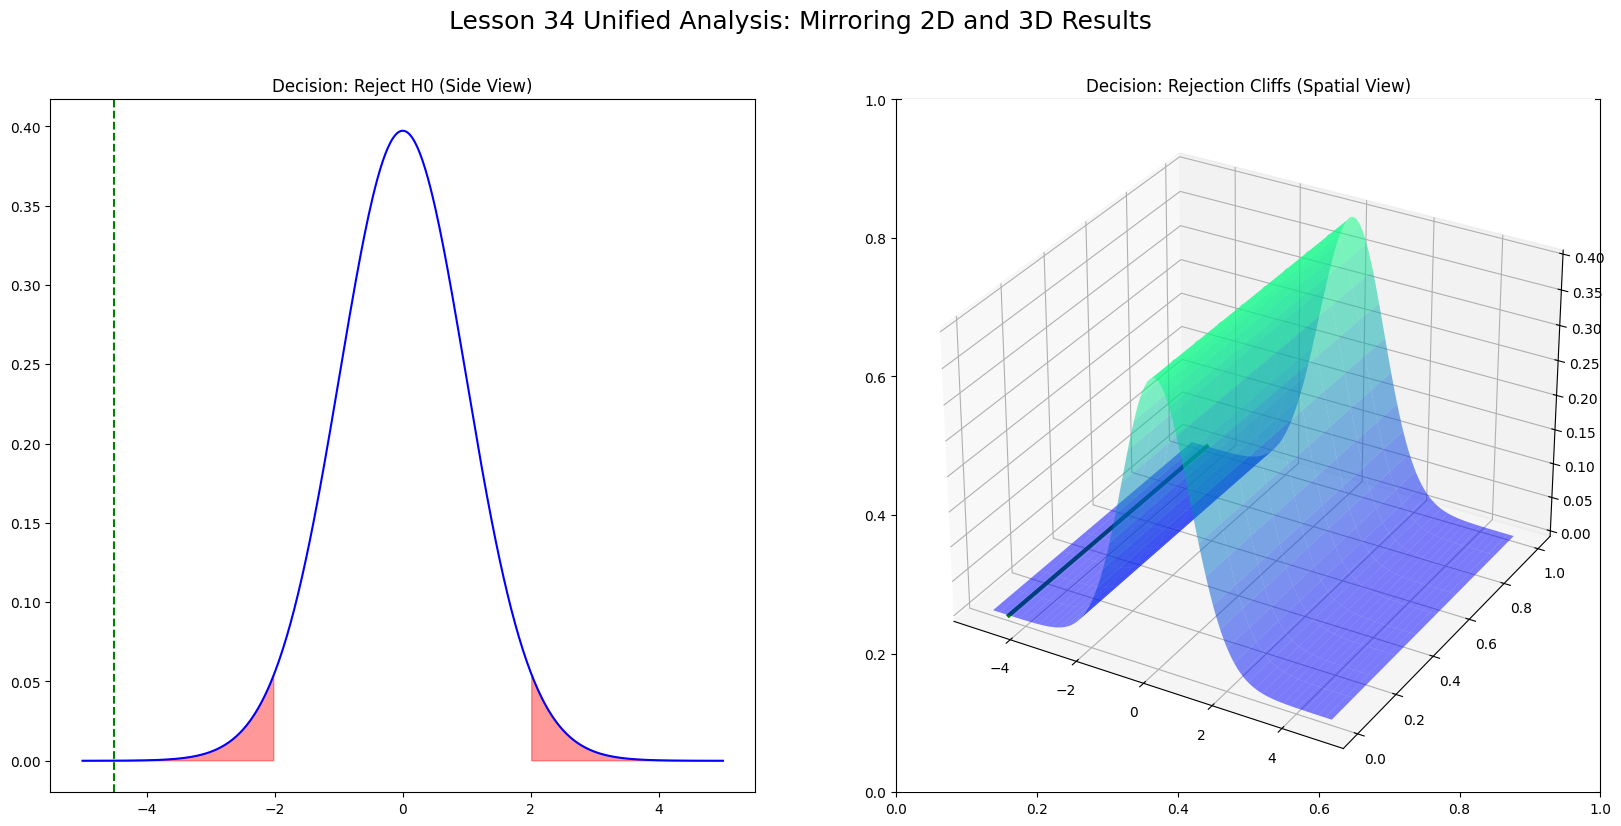

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
import seaborn as sns
import os

def run_hypothesis_testing_fixed():
    asset_path = '../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # 1. Veri Üretimi (Farklı iki sınıf ortalaması)
    np.random.seed(42)
    group_a = np.random.normal(100, 15, 30)
    group_b = np.random.normal(115, 15, 30) # Belirgin fark

    t_stat, p_val = stats.ttest_ind(group_a, group_b)
    df = len(group_a) + len(group_b) - 2
    t_crit = stats.t.ppf(1 - 0.025, df) # %95 güven için kritik sınır

    # --- ASSET 1: 2D (Side View) ---
    fig2d = plt.figure(figsize=(10, 6))
    x = np.linspace(-5, 5, 500)
    y = stats.t.pdf(x, df)
    
    plt.plot(x, y, 'b-', lw=2)
    plt.fill_between(x, 0, y, where=(x > t_crit) | (x < -t_crit), color='red', alpha=0.4, label='Rejection Region')
    plt.axvline(t_stat, color='green', ls='--', lw=3, label=f'T-Stat: {t_stat:.2f}')
    plt.title(f"2D T-Test: P-Value = {p_val:.5f}")
    plt.legend()
    plt.savefig(f'{asset_path}/34_ttest_2d.png', dpi=300)
    plt.close()

    # --- ASSET 2: 3D (Spatial Landscape - FIXED) ---
    # Bu sefer 3D'de sadece t-dağılımını değil, 'Red Bölgelerini' bir yüzey olarak görelim
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    # Y eksenini "Hayali" bir derinlik olarak kullanarak 3D yüzey oluşturma
    Y_depth = np.linspace(0, 1, 10)
    X_grid, Y_grid = np.meshgrid(x, Y_depth)
    Z_grid = stats.t.pdf(X_grid, df)

    # Yüzeyi çiz
    surf = ax3d.plot_surface(X_grid, Y_grid, Z_grid, cmap='winter', alpha=0.6, edgecolor='none')
    
    # 3D'de Red Bölgelerini (Kırmızı Duvarlar) çiz
    # Sağ kuyruk
    x_red = x[x > t_crit]
    X_r, Y_r = np.meshgrid(x_red, Y_depth)
    ax3d.plot_surface(X_r, Y_r, stats.t.pdf(X_r, df), color='red', alpha=0.8)
    # Sol kuyruk
    x_left = x[x < -t_crit]
    X_l, Y_l = np.meshgrid(x_left, Y_depth)
    ax3d.plot_surface(X_l, Y_l, stats.t.pdf(X_l, df), color='red', alpha=0.8)

    # T-Stat Çizgisi (3D'de Yeşil bir "Duvar")
    ax3d.plot([t_stat, t_stat], [0, 1], [0, stats.t.pdf(t_stat, df)], color='green', lw=5)

    ax3d.set_title("3D Statistical Landscape: Rejection Cliffs")
    ax3d.set_xlabel('T-Score'); ax3d.set_zlabel('Probability Density')
    plt.savefig(f'{asset_path}/34_ttest_3d.png', dpi=300)
    plt.close()

    # --- MASTER DASHBOARD ---
    # (Burada her ikisini yan yana göstererek aradaki bağı mühürlüyoruz)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    
    # 2D Görünüm
    ax1.plot(x, y, 'b-')
    ax1.fill_between(x, 0, y, where=(x > t_crit) | (x < -t_crit), color='red', alpha=0.4)
    ax1.axvline(t_stat, color='green', ls='--')
    ax1.set_title("Decision: Reject H0 (Side View)")

    # 3D Görünüm
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X_grid, Y_grid, Z_grid, cmap='winter', alpha=0.5)
    ax2.plot([t_stat, t_stat], [0, 1], [0, stats.t.pdf(t_stat, df)], color='green', lw=3)
    ax2.set_title("Decision: Rejection Cliffs (Spatial View)")
    
    plt.suptitle("Lesson 34 Unified Analysis: Mirroring 2D and 3D Results", fontsize=18)
    plt.show()

if __name__ == "__main__":
    run_hypothesis_testing_fixed()